# Single-cell Experiments




In [1]:
from __future__ import annotations

import json
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True

try:
    import seaborn as sns
    sns.set_context('talk')
except Exception:
    sns = None


def _find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for p in (start, *start.parents):
        if (p / 'pyproject.toml').exists():
            return p
    return start


REPO_ROOT = _find_repo_root(Path.cwd())
for p in (REPO_ROOT, REPO_ROOT / 'src'):
    ps = str(p)
    if ps not in sys.path:
        sys.path.append(ps)


In [2]:
@dataclass
class RunArtifacts:
    run_dir: Path
    metrics: dict | None
    errors: pd.DataFrame | None
    errors_common: pd.DataFrame | None
    errors_by_step: pd.DataFrame | None
    errors_common_by_step: pd.DataFrame | None
    spline_errors: pd.DataFrame | None
    spline_errors_by_step: pd.DataFrame | None
    metrics_by_step: pd.DataFrame | None
    acquisition: dict | None
    metadata: dict | None
    shared_manifest: dict | None


def _read_json(path: Path) -> dict | None:
    if not path.exists():
        return None
    return json.loads(path.read_text())


def _read_csv(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        return None
    return pd.read_csv(path)


def load_run(run_dir: Path) -> RunArtifacts:
    metrics = _read_json(run_dir / 'metrics.json')
    if metrics is not None and 'metrics' in metrics:
        metrics = metrics['metrics']
    errors = _read_csv(run_dir / 'errors.csv')
    errors_common = _read_csv(run_dir / 'errors_common_reference.csv')
    errors_by_step = _read_csv(run_dir / 'errors_by_step.csv')
    errors_common_by_step = _read_csv(run_dir / 'errors_common_reference_by_step.csv')
    spline_errors = _read_csv(run_dir / 'spline_errors.csv')
    spline_errors_by_step = _read_csv(run_dir / 'spline_errors_by_step.csv')
    metrics_by_step = _read_csv(run_dir / 'metrics_by_step.csv')
    acquisition = _read_json(run_dir / 'acquisition_artifacts.json')
    metadata = _read_json(run_dir / 'metadata.json')
    shared_manifest = _read_json(run_dir / 'shared_artifacts' / 'manifest.json')
    return RunArtifacts(
        run_dir=run_dir,
        metrics=metrics,
        errors=errors,
        errors_common=errors_common,
        errors_by_step=errors_by_step,
        errors_common_by_step=errors_common_by_step,
        spline_errors=spline_errors,
        spline_errors_by_step=spline_errors_by_step,
        metrics_by_step=metrics_by_step,
        acquisition=acquisition,
        metadata=metadata,
        shared_manifest=shared_manifest,
    )


In [3]:
def parse_strategy(strategy: str) -> dict[str, str]:
    parts = strategy.split(':') if isinstance(strategy, str) else []
    base = parts[0] if parts else 'unknown'
    if base == 'active':
        acquisition = parts[1] if len(parts) > 1 else 'unknown'
        warp = parts[2] if len(parts) > 2 else 'unknown'
        kernel = parts[-1] if len(parts) > 3 else 'unknown'
    else:
        acquisition = base
        warp = parts[1] if len(parts) > 1 else 'unknown'
        kernel = parts[-1] if len(parts) > 2 else 'unknown'
    return {
        'base': base,
        'acquisition': acquisition,
        'warp': warp,
        'kernel': kernel,
    }


def add_strategy_columns(df: pd.DataFrame | None) -> pd.DataFrame | None:
    if df is None or df.empty or 'strategy' not in df.columns:
        return df
    parsed = df['strategy'].apply(parse_strategy)
    parsed_df = pd.DataFrame(parsed.tolist(), index=df.index)
    out = df.copy()
    for col in ['base', 'acquisition', 'warp', 'kernel']:
        out[col] = parsed_df[col]
    return out


In [4]:
RESULTS_ROOT = REPO_ROOT / 'results'

FINAL_RUN_DIRS = {
    'main': RESULTS_ROOT / 'schibinger_main/2026-05-25_22-52-20',
}

ABLATION_RUN_DIRS = {
    'no_warp': RESULTS_ROOT / 'schibinger_ablation_no_warp/2026-05-25_22-52-20',
    'basis2': RESULTS_ROOT / 'schibinger_ablation_basis2/2026-05-25_22-52-20',
    'fixed_ref': RESULTS_ROOT / 'schibinger_ablation_fixed_ref/2026-05-25_22-52-20',
    'rbf': RESULTS_ROOT / 'schibinger_ablation_rbf/2026-05-25_22-52-20',
}

missing = [
    str(path)
    for path in [*FINAL_RUN_DIRS.values(), *ABLATION_RUN_DIRS.values()]
    if not path.exists()
]
if missing:
    raise FileNotFoundError('Missing run directories:\n' + '\n'.join(missing))

FINAL_RUNS = {label: load_run(path) for label, path in FINAL_RUN_DIRS.items()}

main_runs = [
    {
        'variant': variant,
        'run_dir': run_dir,
        'run': FINAL_RUNS[variant],
    }
    for variant, run_dir in FINAL_RUN_DIRS.items()
]

ablation_runs = [
    {
        'variant': variant,
        'run_dir': run_dir,
        'run': load_run(run_dir),
    }
    for variant, run_dir in ABLATION_RUN_DIRS.items()
]


In [5]:
def _with_run_label(df: pd.DataFrame | None, label: str) -> pd.DataFrame | None:
    if df is None or df.empty:
        return None
    out = add_strategy_columns(df)
    if out is None:
        return None
    out = out.copy()
    out['run'] = label
    return out


metrics_step_all = []
errors_step_all = []
errors_final_all = []

for label, run in FINAL_RUNS.items():
    ms = _with_run_label(run.metrics_by_step, label)
    if ms is not None:
        metrics_step_all.append(ms)

    es = _with_run_label(run.errors_by_step, label)
    if es is not None:
        errors_step_all.append(es)

    ef = _with_run_label(run.errors, label)
    if ef is not None:
        errors_final_all.append(ef)

METRICS_STEP_ALL = pd.concat(metrics_step_all, ignore_index=True) if metrics_step_all else None
ERRORS_STEP_ALL = pd.concat(errors_step_all, ignore_index=True) if errors_step_all else None
ERRORS_FINAL_ALL = pd.concat(errors_final_all, ignore_index=True) if errors_final_all else None


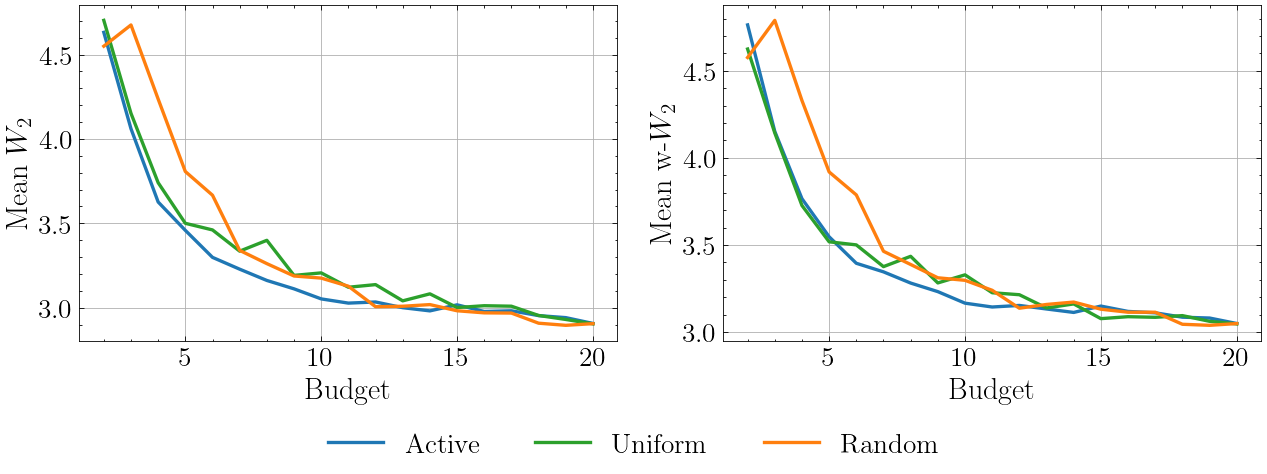

In [6]:
# Clean plots: Active vs Uniform vs Random
import scienceplots  # noqa: F401
from matplotlib.lines import Line2D
plt.style.use(['science'])

MAX_STEP = 20


def _summary_mean(frame: pd.DataFrame, metric: str) -> pd.DataFrame:
    frame = frame.dropna(subset=[metric])
    center = frame.groupby('step')[metric].mean()
    out = pd.DataFrame({'step': center.index, 'mean': center.values})
    return out.sort_values('step')


def _mask_strategy(frame: pd.DataFrame, base: str) -> pd.Series:
    return frame['strategy'].astype(str).str.startswith(f'{base}:')


if METRICS_STEP_ALL is None or METRICS_STEP_ALL.empty:
    print('No metrics_by_step.csv found')
else:
    for label, run in FINAL_RUNS.items():

        metrics_step = add_strategy_columns(run.metrics_by_step)
        if metrics_step is None or metrics_step.empty:
            print(f'[{label}] No metrics_by_step.csv found')
            continue

        df = metrics_step.copy()
        df = df[df['step'] <= MAX_STEP]

        selections = {
            'Active': _mask_strategy(df, 'active'),
            'Uniform': _mask_strategy(df, 'uniform'),
            'Random': _mask_strategy(df, 'random'),
        }

        fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)
        colors = {'Active': '#1f77b4', 'Uniform': '#2ca02c', 'Random': '#ff7f0e'}

        for name, mask in selections.items():
            sub = df[mask].copy()
            if sub.empty:
                print(f'[{label}] No data for {name}')
                continue
            stats_left = _summary_mean(sub, 'uniform_metric')
            stats_right = _summary_mean(sub, 'velocity_metric')
            color = colors.get(name, None)
            axes[0].plot(stats_left['step'] + 1, stats_left['mean'], label=name, color=color, linewidth=2)
            axes[1].plot(stats_right['step'] + 1, stats_right['mean'], label=name, color=color, linewidth=2)

        for ax in axes:
            ax.set_xlabel('Budget')

        axes[0].set_ylabel('Mean $W_2$')
        axes[1].set_ylabel('Mean w-$W_2$')

        legend_handles = [Line2D([], [], color=colors[label], linewidth=2, label=label) for label in selections.keys()]
        fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.01),
                   ncol=3, frameon=False)
        plt.tight_layout(rect=[0, 0.08, 1, 1])

        out_dir = REPO_ROOT / 'figures'
        plt.savefig(out_dir / f'schibinger_{label}.pdf', bbox_inches='tight')
        plt.show()


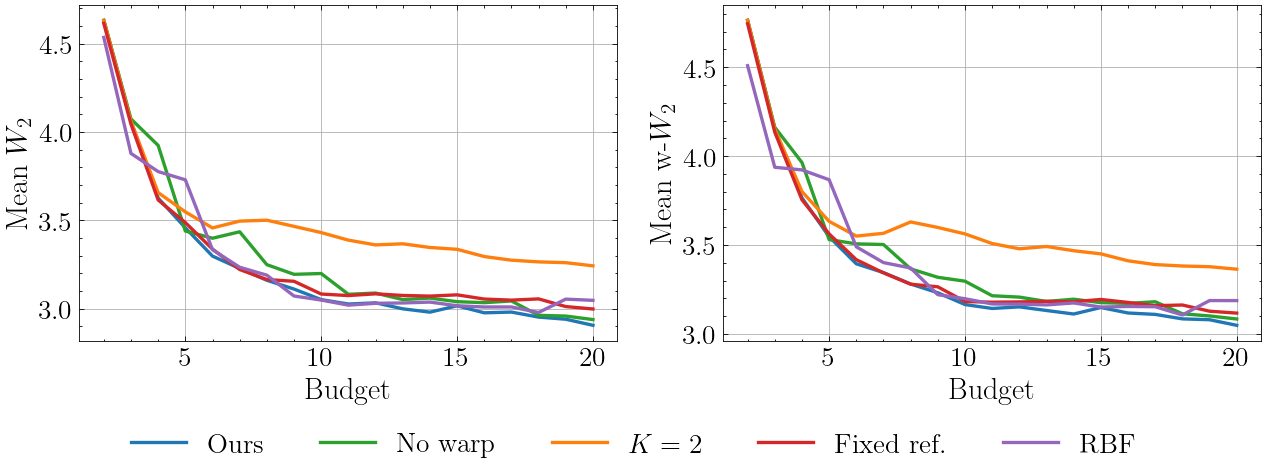

In [7]:
import scienceplots  # noqa: F401
from matplotlib.lines import Line2D
plt.style.use(['science'])

MAX_STEP = 21
VARIANTS = ['main', 'no_warp', 'basis2', 'fixed_ref', 'rbf']
COLORS = {
    'main': '#1f77b4',
    'no_warp': '#2ca02c',
    'basis2': '#ff7f0e',
    'fixed_ref': '#d62728',
    'rbf': '#9467bd',
}
DISPLAY_NAMES = {
    'fixed_ref': 'Fixed ref.',
    'basis2': '$K=2$',
    'no_warp': 'No warp',
    'rbf': 'RBF',
    'main': 'Ours',
}


def _summary_mean(frame: pd.DataFrame, metric: str) -> pd.DataFrame:
    frame = frame.dropna(subset=[metric])
    center = frame.groupby('step')[metric].mean()
    out = pd.DataFrame({'step': center.index, 'mean': center.values})
    return out.sort_values('step')


def _select_active(df: pd.DataFrame) -> pd.DataFrame:
    if 'strategy' not in df.columns:
        return df
    s = df['strategy'].astype(str)
    mask = s.str.startswith('active:')
    sub = df[mask]
    if not sub.empty:
        return sub
    return df


records = (ablation_runs + main_runs) if 'ablation_runs' in globals() and 'main_runs' in globals() else []
if not records:
    print('No ablation runs found')
else:
    subset = [r for r in records if r.get('variant') in VARIANTS]
    if not subset:
        print('No ablation runs found')
    else:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)

        for variant in VARIANTS:
            rec = next((r for r in subset if r.get('variant') == variant), None)
            if rec is None:
                continue
            run = rec['run']

            metrics_step = add_strategy_columns(run.metrics_by_step)
            if metrics_step is None or metrics_step.empty:
                print(f'[{variant}] No metrics_by_step found')
                continue
            ms = _select_active(metrics_step.copy())
            ms = ms[ms['step'] <= MAX_STEP]
            if ms.empty:
                print(f'[{variant}] No active metrics found')
                continue
            stats_left = _summary_mean(ms, 'uniform_metric')
            stats_right = _summary_mean(ms, 'velocity_metric')

            color = COLORS.get(variant, None)
            display_name = DISPLAY_NAMES.get(variant, variant)
            axes[0].plot(stats_left['step'] + 1, stats_left['mean'], label=display_name, color=color, linewidth=2)
            axes[1].plot(stats_right['step'] + 1, stats_right['mean'], label=display_name, color=color, linewidth=2)

        for ax in axes:
            ax.set_xlabel('Budget')

        axes[0].set_ylabel('Mean $W_2$')
        axes[1].set_ylabel('Mean w-$W_2$')

        legend_handles = [Line2D([], [], color=COLORS[v], linewidth=2, label=DISPLAY_NAMES.get(v, v)) for v in VARIANTS if v in COLORS]
        fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.01),
                   ncol=5, frameon=False)
        plt.tight_layout(rect=[0, 0.08, 1, 1])

        plt.savefig(REPO_ROOT / 'figures' / 'schibinger_ablations.pdf', bbox_inches='tight')
        plt.show()
